# Assignment 9

In [2]:
import cv2
import mediapipe as mp
import pandas as pd
import os
import numpy as np
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [ ]:

def extract_mediapipe_to_csv(data_path: str, save_path: str, model_path: str):

    video_extensions = [".mp4", ".mov", ".avi", ".mkv"]
    static = not any(data_path.lower().endswith(ext) for ext in video_extensions)

    base_options = python.BaseOptions(model_asset_path=model_path)

    JOINT_ORDER = [
        "head",
        "left_shoulder", "left_elbow",
        "right_shoulder", "right_elbow",
        "left_hand", "right_hand",
        "left_hip", "right_hip",
        "left_knee", "right_knee",
        "left_foot", "right_foot"
    ]

    LANDMARK_INDEX = {
        "head": 0,  
        "left_shoulder": 11,
        "right_shoulder": 12,
        "left_elbow": 13,
        "right_elbow": 14,
        "left_hand": 15,
        "right_hand": 16,
        "left_hip": 23,
        "right_hip": 24,
        "left_knee": 25,
        "right_knee": 26,
        "left_foot": 27,
        "right_foot": 28,
    }

    data = []

    if static:
        options = vision.PoseLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.IMAGE,
            min_pose_detection_confidence=0.5,
            min_pose_presence_confidence=0.5
        )

        with vision.PoseLandmarker.create_from_options(options) as landmarker:
            image = cv2.imread(data_path)
            if image is None:
                raise ValueError(f"Could not read image: {data_path}")

            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
            results = landmarker.detect(mp_image)

            if results.pose_landmarks:
                row = {"FrameNo": 0}

                for joint in JOINT_ORDER:
                    idx = LANDMARK_INDEX[joint]
                    lm = results.pose_landmarks[0][idx]

                    row[f"{joint}_x"] = lm.x
                    row[f"{joint}_y"] = lm.y
                    row[f"{joint}_z"] = lm.z

                data.append(row)

    else:
        options = vision.PoseLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.VIDEO,
            min_pose_detection_confidence=0.5,
            min_pose_presence_confidence=0.5,
            min_tracking_confidence=0.5
        )

        with vision.PoseLandmarker.create_from_options(options) as landmarker:
            cap = cv2.VideoCapture(data_path)

            if not cap.isOpened():
                raise ValueError(f"Could not open video: {data_path}")

            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_idx = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

                timestamp_ms = int((frame_idx / fps) * 1000)
                results = landmarker.detect_for_video(mp_image, timestamp_ms)

                if results.pose_landmarks:
                    row = {"FrameNo": frame_idx}

                    for joint in JOINT_ORDER:
                        idx = LANDMARK_INDEX[joint]
                        lm = results.pose_landmarks[0][idx]

                        row[f"{joint}_x"] = lm.x
                        row[f"{joint}_y"] = lm.y
                        row[f"{joint}_z"] = lm.z

                    data.append(row)

                frame_idx += 1

            cap.release()

    # ---- SAVE CSV ----
    columns = ["FrameNo"]
    for joint in JOINT_ORDER:
        columns += [f"{joint}_x", f"{joint}_y", f"{joint}_z"]

    df = pd.DataFrame(data)
    df = df[columns]

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(save_path, index=False)

    print(f"Saved {len(df)} rows to {save_path}")

In [11]:

def extract_mediapipe_to_csv_world(data_path: str, save_path: str, model_path: str):

    video_extensions = [".mp4", ".mov", ".avi", ".mkv"]
    static = not any(data_path.lower().endswith(ext) for ext in video_extensions)

    base_options = python.BaseOptions(model_asset_path=model_path)

    JOINT_ORDER = [
        "head",
        "left_shoulder", "left_elbow",
        "right_shoulder", "right_elbow",
        "left_hand", "right_hand",
        "left_hip", "right_hip",
        "left_knee", "right_knee",
        "left_foot", "right_foot"
    ]

    LANDMARK_INDEX = {
        "head": 0,  
        "left_shoulder": 11,
        "right_shoulder": 12,
        "left_elbow": 13,
        "right_elbow": 14,
        "left_hand": 15,
        "right_hand": 16,
        "left_hip": 23,
        "right_hip": 24,
        "left_knee": 25,
        "right_knee": 26,
        "left_foot": 27,
        "right_foot": 28,
    }

    data = []

    if static:
        options = vision.PoseLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.IMAGE,
            min_pose_detection_confidence=0.5,
            min_pose_presence_confidence=0.5
        )

        with vision.PoseLandmarker.create_from_options(options) as landmarker:
            image = cv2.imread(data_path)
            if image is None:
                raise ValueError(f"Could not read image: {data_path}")

            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
            results = landmarker.detect(mp_image)

            if results.pose_world_landmarks:
                row = {"FrameNo": 0}

                for joint in JOINT_ORDER:
                    idx = LANDMARK_INDEX[joint]
                    lm = results.pose_world_landmarks[0][idx]

                    row[f"{joint}_x"] = lm.x
                    row[f"{joint}_y"] = lm.y
                    row[f"{joint}_z"] = lm.z

                data.append(row)

    else:
        options = vision.PoseLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.VIDEO,
            min_pose_detection_confidence=0.5,
            min_pose_presence_confidence=0.5,
            min_tracking_confidence=0.5
        )

        with vision.PoseLandmarker.create_from_options(options) as landmarker:
            cap = cv2.VideoCapture(data_path)

            if not cap.isOpened():
                raise ValueError(f"Could not open video: {data_path}")

            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_idx = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

                timestamp_ms = int((frame_idx / fps) * 1000)
                results = landmarker.detect_for_video(mp_image, timestamp_ms)

                if results.pose_world_landmarks:
                    row = {"FrameNo": frame_idx}

                    for joint in JOINT_ORDER:
                        idx = LANDMARK_INDEX[joint]
                        lm = results.pose_world_landmarks[0][idx]

                        row[f"{joint}_x"] = lm.x
                        row[f"{joint}_y"] = lm.y
                        row[f"{joint}_z"] = lm.z

                    data.append(row)

                frame_idx += 1

            cap.release()

    # ---- SAVE CSV ----
    columns = ["FrameNo"]
    for joint in JOINT_ORDER:
        columns += [f"{joint}_x", f"{joint}_y", f"{joint}_z"]

    df = pd.DataFrame(data)
    df = df[columns]

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(save_path, index=False)

    print(f"Saved {len(df)} rows to {save_path}")

In [3]:
extract_mediapipe_to_csv(
    data_path="../data/still_video.mov",
    save_path="../data/still_video_mediapipe.csv",
    model_path="../data/pose_landmarker.task"
)

I0000 00:00:1776751039.445397  105158 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776751039.614112  109410 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776751039.653506  109406 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776751039.867260  109410 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Saved 105 rows to ../data/still_video_mediapipe.csv


In [65]:
extract_mediapipe_to_csv_world(
    data_path="../data/1m_step_high.mov",
    save_path="../data/1m_step_high_world_mediapipe.csv",
    model_path="../data/pose_landmarker.task"
)
#     data_path="../../../all_videos/A1.avi",

#    data_path="../data/still_video.mov",


I0000 00:00:1776753650.434909  105158 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2
W0000 00:00:1776753650.628456  139076 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776753650.670076  139080 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Saved 397 rows to ../data/1m_step_high_world_mediapipe.csv


### Save video to csv

In [5]:
""""
video_folder = "../data"
model_path = "../data/pose_landmarker.task"
output_folder = "../data"

video_extensions = [".mp4", ".mov", ".avi", ".mkv"]

for file_name in os.listdir(video_folder):
    
    if not any(file_name.lower().endswith(ext) for ext in video_extensions):
        continue

    video_path = os.path.join(video_folder, file_name)

    base_name = os.path.splitext(file_name)[0]
    save_name = f"{base_name}_mediapipe.csv"
    save_path = os.path.join(output_folder, save_name)

    print(f"Processing: {file_name}")

    extract_mediapipe_to_csv(
        data_path=video_path,
        save_path=save_path,
        model_path=model_path
    )
print("Done.")
"""

'"\nvideo_folder = "../data"\nmodel_path = "../data/pose_landmarker.task"\noutput_folder = "../data"\n\nvideo_extensions = [".mp4", ".mov", ".avi", ".mkv"]\n\nfor file_name in os.listdir(video_folder):\n\n    if not any(file_name.lower().endswith(ext) for ext in video_extensions):\n        continue\n\n    video_path = os.path.join(video_folder, file_name)\n\n    base_name = os.path.splitext(file_name)[0]\n    save_name = f"{base_name}_mediapipe.csv"\n    save_path = os.path.join(output_folder, save_name)\n\n    print(f"Processing: {file_name}")\n\n    extract_mediapipe_to_csv(\n        data_path=video_path,\n        save_path=save_path,\n        model_path=model_path\n    )\nprint("Done.")\n'

### Functions for comparing

In [3]:
def euclidean_2d(x1, y1, x2, y2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

def euclidean_3d(x1, y1, z1, x2, y2, z2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2 + (z1 - z2) ** 2)



def add_3D_distances(df):
    df = df.copy()
    df["hip_to_shoulder"] = euclidean_3d(df["left_hip_x"], df["left_hip_y"], df["left_hip_z"],
                                         df["left_shoulder_x"], df["left_shoulder_y"], df["left_shoulder_z"])
    df["knee_to_hip"] = euclidean_3d(df["left_knee_x"], df["left_knee_y"], df["left_knee_z"],
                                     df["left_hip_x"], df["left_hip_y"], df["left_hip_z"])
    df["hip_to_hip"] = euclidean_3d(df["left_hip_x"], df["left_hip_y"], df["left_hip_z"],
                                    df["right_hip_x"], df["right_hip_y"], df["right_hip_z"])
    df["knee_to_ankle"] = euclidean_3d(df["left_knee_x"], df["left_knee_y"], df["left_knee_z"],
                                       df["left_foot_x"], df["left_foot_y"], df["left_foot_z"])
    df["shoulder_to_shoulder"] = euclidean_3d(df["left_shoulder_x"], df["left_shoulder_y"], df["left_shoulder_z"],
                                              df["right_shoulder_x"], df["right_shoulder_y"], df["right_shoulder_z"])
    return df


def add_2D_distances(df):
    df = df.copy()
    df["hip_to_shoulder"]        = euclidean_2d(df["left_hip_x"], df["left_hip_y"],
                                        df["left_shoulder_x"], df["left_shoulder_y"])
    df["knee_to_hip"]            = euclidean_2d(df["left_knee_x"], df["left_knee_y"],
                                        df["left_hip_x"], df["left_hip_y"])
    df["hip_to_hip"]             = euclidean_2d(df["left_hip_x"], df["left_hip_y"],
                                        df["right_hip_x"], df["right_hip_y"])
    df["knee_to_ankle"]          = euclidean_2d(df["left_knee_x"], df["left_knee_y"],
                                        df["left_foot_x"], df["left_foot_y"])
    df["shoulder_to_shoulder"]   = euclidean_2d(df["left_shoulder_x"], df["left_shoulder_y"],
                                        df["right_shoulder_x"], df["right_shoulder_y"])
    return df


def convert_to_pixel_coordinates(df, frame_width, frame_height):

    joints = [
        "head",
        "left_shoulder", "right_shoulder",
        "left_elbow", "right_elbow",
        "left_hand", "right_hand",
        "left_hip", "right_hip",
        "left_knee", "right_knee",
        "left_foot", "right_foot"
    ]
    
    df = df.copy()

    for joint in joints:
        df[f"{joint}_x"] = df[f"{joint}_x"] * frame_width
        df[f"{joint}_y"] = df[f"{joint}_y"] * frame_height
    return df

def align_by_frame(mp_df, kinect_df):
    # Get Kinect frames
    kinect_frames = kinect_df["FrameNo"].values
    mp_aligned = mp_df[mp_df["FrameNo"].isin(kinect_frames)].copy()
    mp_aligned = mp_aligned.reset_index(drop=True)
    kinect_aligned = kinect_df.reset_index(drop=True)

    return mp_aligned, kinect_aligned


def print_comparison_table(avg, ground_truth, scale, reference):

    all_errors = []

    print(f"{'Limb':<25} {'Tape (cm)':>10} {'MediaPipe (cm)':>15} {'Error (cm)':>12} {'Error (%)':>10}")
    print("-" * 75)

    for key, true_val in ground_truth.items():
        mp_val = avg[key] * scale
        error = abs(mp_val - true_val)
        error_pct = (error / true_val) * 100 if true_val != 0 else 0
        if key != reference:
            all_errors.append(error)
        print(f"{key:<25} {true_val:>10.1f} {mp_val:>15.1f} {error:>12.1f} {error_pct:>10.1f}%")

    print("-" * 75)
    print(f"{'Average error':<25} {'':>10} {'':>15} {np.mean(all_errors):>12.1f}")


def print_kinect_mp_comparison(kinect_dist, mp_scaled, errors):

    distance_names = [
        "hip_to_shoulder",
        "knee_to_hip",
        "hip_to_hip",
        "knee_to_ankle",
        "shoulder_to_shoulder"]

    print(f"{'Measurement':<25} {'Kinect':>12} {'MediaPipe':>12} {'Error':>12} {'Error %':>10}")
    print("-" * 75)

    all_errors = []

    for col in distance_names:
        kinect_avg = kinect_dist[col].mean()
        mp_avg = mp_scaled[col].mean()
        error_avg = errors[col].mean()
        error_pct = (error_avg / kinect_avg) * 100 if kinect_avg != 0 else 0
        all_errors.append(error_avg)

        print(f"{col:<25} {kinect_avg * 100:>12.1f} {mp_avg * 100:>12.1f} {error_avg * 100:>12.1f} {error_pct:>10.1f}%")

    print("-" * 75)
    print(f"{'Average error':<25} {'':>12} {'':>12} {np.mean(all_errors) * 100:>12.1f}")


### Joint of Enis

In [15]:
ground_truth = {
    "hip_to_shoulder":      55,
    "knee_to_hip":          47,
    "hip_to_hip":           25,
    "knee_to_ankle":        43,
    "shoulder_to_shoulder": 38
}

## Ground truth vs Mediapipe

### 2D Joint Distance Estimation from a Static Video


In [16]:
df = pd.read_csv("../data/still_video_mediapipe.csv")


REFERENCE = "hip_to_shoulder"


df = convert_to_pixel_coordinates(df, 1920, 1080)
df_dist = add_2D_distances(df)

avg = df_dist[[
    "hip_to_shoulder",
    "knee_to_hip",
    "hip_to_hip",
    "knee_to_ankle",
    "shoulder_to_shoulder"
]].mean()


scale = ground_truth[REFERENCE] / avg[REFERENCE]
print(f"Scale factor: {scale:.2f} cm per unit\n")

print_comparison_table(
    avg=avg,
    ground_truth=ground_truth,
    scale=scale,
    reference=REFERENCE)

Scale factor: 0.18 cm per unit

Limb                       Tape (cm)  MediaPipe (cm)   Error (cm)  Error (%)
---------------------------------------------------------------------------
hip_to_shoulder                 55.0            55.0          0.0        0.0%
knee_to_hip                     47.0            46.1          0.9        1.9%
hip_to_hip                      25.0            21.6          3.4       13.6%
knee_to_ankle                   43.0            38.9          4.1        9.5%
shoulder_to_shoulder            38.0            34.5          3.5        9.3%
---------------------------------------------------------------------------
Average error                                                 3.0


### 3D Joint Distance Estimation from a Static Video


In [17]:
df = pd.read_csv("../data/still_video_world_mediapipe.csv")

REFERENCE = "hip_to_shoulder"


df_dist = add_3D_distances(df)

avg = df_dist[[
    "hip_to_shoulder",
    "knee_to_hip",
    "hip_to_hip",
    "knee_to_ankle",
    "shoulder_to_shoulder"
]].mean()


scale = ground_truth[REFERENCE] / avg[REFERENCE]
print(f"Scale factor: {scale:.2f} cm per unit\n")

print_comparison_table(
    avg=avg,
    ground_truth=ground_truth,
    scale=scale,
    reference=REFERENCE)

Scale factor: 112.11 cm per unit

Limb                       Tape (cm)  MediaPipe (cm)   Error (cm)  Error (%)
---------------------------------------------------------------------------
hip_to_shoulder                 55.0            55.0          0.0        0.0%
knee_to_hip                     47.0            46.3          0.7        1.5%
hip_to_hip                      25.0            25.7          0.7        2.7%
knee_to_ankle                   43.0            42.6          0.4        0.9%
shoulder_to_shoulder            38.0            36.1          1.9        4.9%
---------------------------------------------------------------------------
Average error                                                 0.9


### 3D Joint Distance Estimation from a Dynamic Video


In [11]:
df = pd.read_csv("../data/1m_step_high_world_mediapipe.csv")

REFERENCE = "hip_to_shoulder"

df_dist = add_3D_distances(df)

avg = df_dist[[
    "hip_to_shoulder",
    "knee_to_hip",
    "hip_to_hip",
    "knee_to_ankle",
    "shoulder_to_shoulder"
]].mean()


scale = ground_truth[REFERENCE] / avg[REFERENCE]
print(f"Scale factor: {scale:.2f} cm per unit\n")

print_comparison_table(
    avg=avg,
    ground_truth=ground_truth,
    scale=scale,
    reference=REFERENCE)

Scale factor: 113.81 cm per unit

Limb                       Tape (cm)  MediaPipe (cm)   Error (cm)  Error (%)
---------------------------------------------------------------------------
hip_to_shoulder                 55.0            55.0          0.0        0.0%
knee_to_hip                     47.0            47.9          0.9        1.9%
hip_to_hip                      25.0            25.5          0.5        2.0%
knee_to_ankle                   43.0            41.9          1.1        2.7%
shoulder_to_shoulder            38.0            36.6          1.4        3.7%
---------------------------------------------------------------------------
Average error                                                 1.0


## Kinect Vs Mediapipe

### 3D Joint Distance Comparison Between Kinect and MediaPipe from a Dynamic Video


In [14]:
kinect_df = pd.read_csv("../../MainProject/Assignment9/data/kinect_good_preprocessed/A1_kinect.csv")
mp_df = pd.read_csv("../data/A1_world_mediapipe.csv")


REFERENCE = "hip_to_shoulder"



mp_aligned, kinect_ = align_by_frame(mp_df, kinect_df)

kinect_dist = add_3D_distances(kinect_)
mp_dist = add_3D_distances(mp_aligned)


scale = kinect_dist[REFERENCE].mean() / mp_dist[REFERENCE].mean()
mp_scaled = mp_dist * scale


errors = abs(mp_scaled - kinect_dist)
print(f"Scale factor: {scale:.4f}\n")


print_kinect_mp_comparison(
    kinect_dist=kinect_dist,
    mp_scaled=mp_scaled,
    errors=errors,)


Scale factor: 0.9597

Measurement                     Kinect    MediaPipe        Error    Error %
---------------------------------------------------------------------------
hip_to_shoulder                   50.1         50.1          1.0        1.9%
knee_to_hip                       36.0         37.0          1.6        4.5%
hip_to_hip                        14.7         21.5          6.9       47.0%
knee_to_ankle                     37.8         33.5          4.3       11.4%
shoulder_to_shoulder              29.4         28.7          1.5        5.2%
---------------------------------------------------------------------------
Average error                                                3.1


### Plot and compate distances

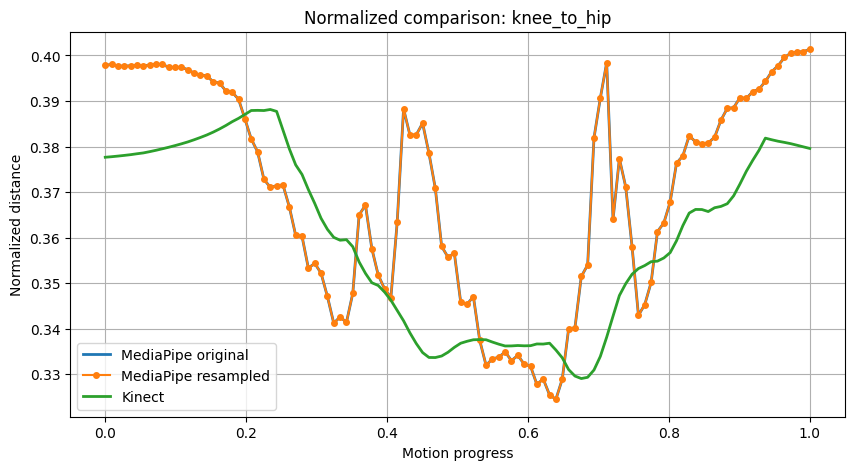

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Pick one distance signal
signal_name = "knee_to_hip"

# Get raw signals
mp_original = mp_dist[signal_name].values
mp_resampled_signal = mp_dist[signal_name].values
kinect_signal = kinect_dist[signal_name].values

mp_original = mp_original * scale
mp_resampled_signal = mp_resampled_signal * scale
kinect_signal

# x-axes as motion progress
x_mp_original = np.linspace(0, 1, len(mp_original))
x_mp_resampled = np.linspace(0, 1, len(mp_resampled_signal))
x_kinect = np.linspace(0, 1, len(kinect_signal))

# Plot
plt.figure(figsize=(10, 5))

plt.plot(x_mp_original, mp_original, label="MediaPipe original", linewidth=2)
plt.plot(x_mp_resampled, mp_resampled_signal, "o-", label="MediaPipe resampled", markersize=4)
plt.plot(x_kinect, kinect_signal, label="Kinect", linewidth=2)

plt.title(f"Normalized comparison: {signal_name}")
plt.xlabel("Motion progress")
plt.ylabel("Normalized distance")
plt.legend()
plt.grid()
plt.show()